In [180]:
import pickle
import os
from pprint import pprint
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Choose a pickle file (modify this path as needed)
#pickle_file_path = "../results/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250715_080223_steps_80000_bs_4_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"
#pickle_file_path = "../results/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250715_133303_steps_800_bs_4_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"
#pickle_file_path = "../sweeps/sparse/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250716_075607_steps_10000_bs_32_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"
#pickle_file_path = "../sweeps/sparse/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250716_062750_steps_60000_bs_32_seq_1024_devices_1_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_cudnn.pkl"
#pickle_file_path = "/Users/elliotpaquette/Dropbox/Tanea/nanogpt_tanea_results_mixed_bf16_rope_multi_gpu_20250716_060754_steps_120000_bs_32_seq_1024_devices_4_g2_0.00016_g3_0.00016_delta_8.0_flavor_mk3_attn_naive_wsd_0.02_0.2.pkl"
pickle_file_path ="./gpt-medium.pkl"

Inspect the contents of the file and output the config information

In [181]:

# Load and inspect the pickle file
try:
    with open(pickle_file_path, 'rb') as f:
        data = pickle.load(f)
    
    print("=== PICKLE FILE CONTENTS ===")
    print(f"Type: {type(data)}")
    print(f"File: {pickle_file_path}")
    print("\n=== FULL CONTENTS ===")
    if isinstance(data, dict):
        print("Keys in the loaded pickle file:")
        for key in data.keys():
            print(f"- {key}")
    else:
        print("Loaded object is not a dict. Type:", type(data))
        print("Attributes:")
        for attr in dir(data):
            if not attr.startswith("__"):
                print(f"- {attr}")
    
    print("\n=== CONFIG KEY ===")
    if isinstance(data, dict) and 'config' in data:
        pprint(data['config'])
    elif hasattr(data, 'config'):
        pprint(data.config)
    else:
        print("No 'config' key found in the data")
        if isinstance(data, dict):
            print(f"Available keys: {list(data.keys())}")
        else:
            print(f"Data attributes: {dir(data)}")
            
except FileNotFoundError:
    print(f"File not found: {pickle_file_path}")
    print("Please update the pickle_file_path variable with the correct path")
except Exception as e:
    print(f"Error loading pickle file: {e}")


=== PICKLE FILE CONTENTS ===
Type: <class 'dict'>
File: ./gpt-medium.pkl

=== FULL CONTENTS ===
Keys in the loaded pickle file:
- metrics
- tau_statistics
- config
- num_params
- precision
- multi_gpu
- num_devices

=== CONFIG KEY ===
{'attention_implementation': 'naive',
 'batch_size': 32,
 'clipsnr': 1.6,
 'decay_fraction': 0.2,
 'disable_checkpoint': True,
 'disable_validation': False,
 'enable_wsd': True,
 'grad_clip': 100.0,
 'init_std': 0.02,
 'model_size': 'GPT2-medium',
 'momentum_flavor': 'mk3',
 'num_devices': 4,
 'per_device_batch_size': 8,
 'per_device_val_batch_size': 8,
 'power_weight_decay': 1.0,
 'precision': 'mixed_bfloat16_rope',
 'results_dir': '/home/c/cypaquet/Experimental/ccanada/nanogpt_speedrun_results_20250715_191659',
 'rope_base': 10000.0,
 'seq_len': 1024,
 'tanea_delta': 8.0,
 'tanea_g2': 0.00016,
 'tanea_g3': 0.00016,
 'tanea_kappa': 0.75,
 'train_steps': 120000,
 'val_batch_size': 32,
 'val_max_tokens': 163840,
 'val_steps': 4,
 'warmup_fraction': 0.02,
 

Plot the loss curve

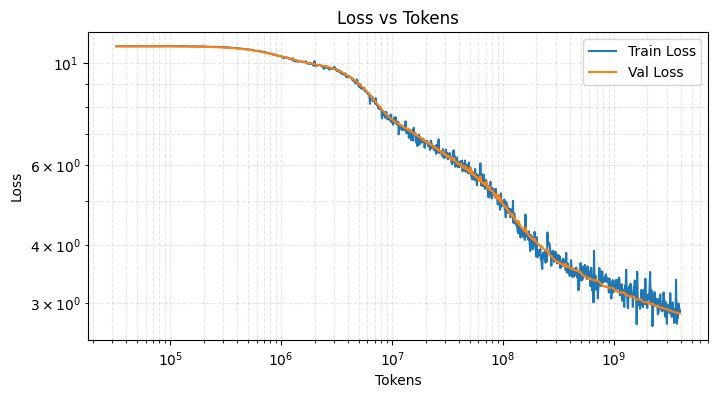

In [182]:
steps = data['metrics']['step']
train_losses = data['metrics']['train_loss']
val_losses = data['metrics']['val_loss']
tokens_per_step = data['config']['batch_size'] * data['config']['seq_len']
tokens = np.array(steps) * tokens_per_step

plt.figure(figsize=(8, 4))
plt.plot(tokens, train_losses)
plt.plot(tokens, val_losses)
plt.legend(['Train Loss', 'Val Loss'])
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.xlabel('Tokens')
plt.ylabel('Loss')
plt.title('Loss vs Tokens')
plt.xscale('log')
plt.yscale('log')
plt.show()


Plot the tau statistics

In [183]:
for k in list(data['tau_statistics']['tau_statistics'][0]['params'].keys()):
    print(k)

TransformerBlock_0
TransformerBlock_1
TransformerBlock_10
TransformerBlock_11
TransformerBlock_12
TransformerBlock_13
TransformerBlock_14
TransformerBlock_15
TransformerBlock_16
TransformerBlock_17
TransformerBlock_18
TransformerBlock_19
TransformerBlock_2
TransformerBlock_20
TransformerBlock_21
TransformerBlock_22
TransformerBlock_23
TransformerBlock_3
TransformerBlock_4
TransformerBlock_5
TransformerBlock_6
TransformerBlock_7
TransformerBlock_8
TransformerBlock_9
head
ln_f
wte


In [ ]:
# Let's explore the structure of a single transformer block to understand all available layers
block_0 = data['tau_statistics']['tau_statistics'][0]['params']['TransformerBlock_0']
print("TransformerBlock_0 structure:")
for key in block_0.keys():
    print(f"  {key}:")
    if isinstance(block_0[key], dict):
        for subkey in block_0[key].keys():
            print(f"    {subkey}:")
            if isinstance(block_0[key][subkey], dict):
                for subsubkey in block_0[key][subkey].keys():
                    print(f"      {subsubkey}")
            else:
                print(f"      (data)")
    else:
        print(f"    (data)")

In [184]:
data['num_params']

405288017

In [185]:
data['tau_statistics']['tau_statistics'][14]['params']['TransformerBlock_10']['CausalSelfAttention_0']['k_proj']['kernel'][1]

array([0.1669086 , 0.16694102, 0.16919418, 0.17024992, 0.17823479,
       0.179527  , 0.17970304, 0.17995915, 0.18033504, 0.18250567,
       0.182572  , 0.1852531 , 0.18525958, 0.18623452, 0.18765092,
       0.18906103, 0.18965878, 0.1897252 , 0.19078784, 0.19317184,
       0.19374172, 0.19526902, 0.19589575, 0.19643092, 0.19791627,
       0.19851913, 0.19975223, 0.20086235, 0.20185816, 0.20262277,
       0.20389828, 0.20470136, 0.20566484, 0.20644869, 0.20805393,
       0.2094707 , 0.21095923, 0.21203333, 0.2129006 , 0.21371168,
       0.21504024, 0.21647692, 0.21754566, 0.21878058, 0.21971522,
       0.22076122, 0.2217267 , 0.22309154, 0.224387  , 0.22541402,
       0.2267637 , 0.22813341, 0.22951229, 0.23101152, 0.23245592,
       0.23401341, 0.23576437, 0.23725726, 0.23891497, 0.24064736,
       0.24207373, 0.24393374, 0.24553405, 0.24721631, 0.249139  ,
       0.25116193, 0.25302938, 0.25483966, 0.25684533, 0.2586206 ,
       0.26062393, 0.26259774, 0.26438594, 0.2665774 , 0.26852

Plot layer statistics

In [188]:
# Configure which layer to analyze
# Examples:
#layer_path = ['head', 'kernel']
#layer_path = ['TransformerBlock_1', 'MLP_0', 'fc1', 'kernel']
#layer_path = ['TransformerBlock_1', 'MLP_0', 'fc2', 'kernel']
#layer_path = ['TransformerBlock_23', 'CausalSelfAttention_0', 'q_proj', 'kernel']
#layer_path = ['TransformerBlock_0', 'CausalSelfAttention_0', 'k_proj', 'kernel']
layer_path = ['TransformerBlock_0', 'CausalSelfAttention_0', 'v_proj', 'kernel']
#layer_path = ['wte', 'embedding']
#layer_path = ['head', 'kernel']

## Configurable Layer Analysis

You can now easily change which layer to analyze by modifying the `layer_path` variable below. Here are some examples:

- `['head', 'kernel']` - Analyzes the head layer kernel
- `['TransformerBlock_10', 'MLP_0', 'fc2', 'kernel']` - Analyzes the fc2 kernel in MLP_0 of TransformerBlock_10
- `['wte', 'embeddings']` - Analyzes the word token embeddings
- `['TransformerBlock_0', 'SelfAttention_0', 'query', 'kernel']` - Analyzes the query kernel in the first transformer block

The plot will automatically update to show both largest and smallest order statistics for the selected layer.

/opt/e-py/lib/python3.12/site-packages/numpy/_core/numeric.py:452: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


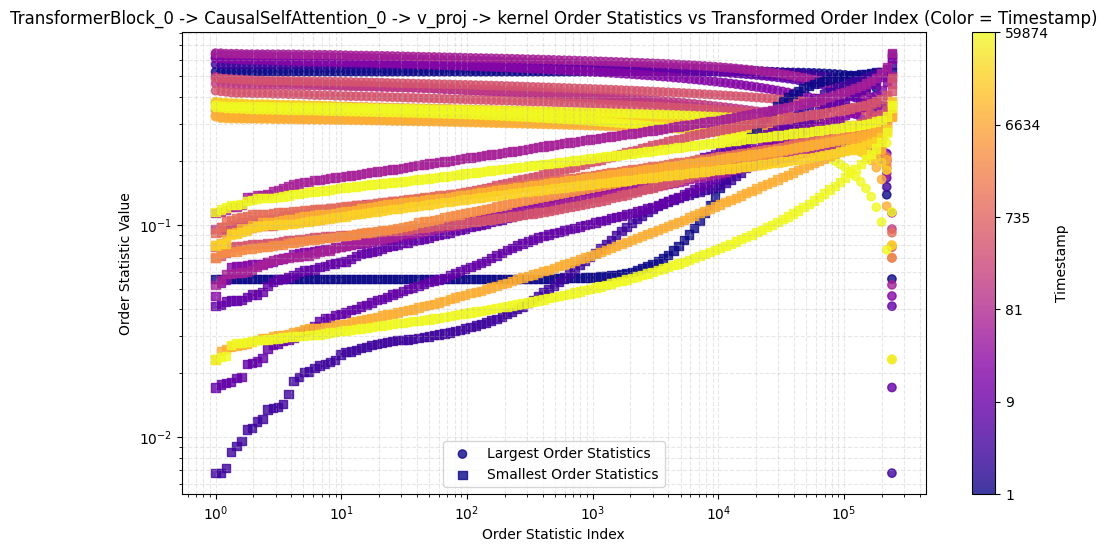

In [189]:
timestamps = data['tau_statistics']['timestamps']
all_order_statistics = data['tau_statistics']['tau_statistics']

# Helper function to access nested dictionary with path
def get_nested_value(data, path):
    for key in path:
        data = data[key]
    return data

# Prepare data for combined plot
order_indices_largest = []
order_values_largest = []
order_timestamps_largest = []

order_indices_smallest = []
order_values_smallest = []
order_timestamps_smallest = []

for t_idx, (ts, arr) in enumerate(zip(timestamps, all_order_statistics)):
    # Get largest order statistics (index 0)
    arr_largest = np.asarray(get_nested_value(arr['params'], layer_path)[0])
    for order_idx, val in enumerate(arr_largest):
        # Transform k to K = (1.1 ** k)
        K = 1.1 ** order_idx
        order_indices_largest.append(K)
        order_values_largest.append(val)
        order_timestamps_largest.append(ts)
    
    # Get smallest order statistics (index 1)
    arr_smallest = np.asarray(get_nested_value(arr['params'], layer_path)[1])
    for order_idx, val in enumerate(arr_smallest):
        # Transform k to K = (1.1 ** k)
        K = 1.1 ** order_idx
        order_indices_smallest.append(K)
        order_values_smallest.append(val)
        order_timestamps_smallest.append(ts)

# Convert to numpy arrays
order_indices_largest = np.array(order_indices_largest)
order_values_largest = np.array(order_values_largest)
order_timestamps_largest = np.array(order_timestamps_largest)

order_indices_smallest = np.array(order_indices_smallest)
order_values_smallest = np.array(order_values_smallest)
order_timestamps_smallest = np.array(order_timestamps_smallest)

# Create combined plot
plt.figure(figsize=(12, 6))

# Use log of order_timestamps for color, but keep original timestamps for colorbar ticks
# Filter out zero and negative values to avoid log warnings
valid_mask_largest = order_timestamps_largest > 0
valid_mask_smallest = order_timestamps_smallest > 0

log_order_timestamps_largest = np.full_like(order_timestamps_largest, np.nan)
log_order_timestamps_largest[valid_mask_largest] = np.log(order_timestamps_largest[valid_mask_largest])

log_order_timestamps_smallest = np.full_like(order_timestamps_smallest, np.nan)
log_order_timestamps_smallest[valid_mask_smallest] = np.log(order_timestamps_smallest[valid_mask_smallest])

# Plot both largest and smallest order statistics
sc1 = plt.scatter(order_indices_largest, order_values_largest, c=log_order_timestamps_largest, 
                  cmap='plasma', alpha=0.8, label='Largest Order Statistics', marker='o')
sc2 = plt.scatter(order_indices_smallest, order_values_smallest, c=log_order_timestamps_smallest, 
                  cmap='plasma', alpha=0.8, label='Smallest Order Statistics', marker='s')

plt.xlabel('Order Statistic Index')
plt.ylabel('Order Statistic Value')
layer_name = ' -> '.join(layer_path)
plt.title(f'{layer_name} Order Statistics vs Transformed Order Index (Color = Timestamp)')
plt.legend()

# Create colorbar with ticks labeled as order_timestamps
cbar = plt.colorbar(sc1)
cbar.set_label('Timestamp')

# Set colorbar ticks to correspond to a few representative timestamps
num_ticks = 6
all_timestamps = np.concatenate([order_timestamps_largest, order_timestamps_smallest])
all_log_timestamps = np.concatenate([log_order_timestamps_largest, log_order_timestamps_smallest])
valid_mask_all = all_timestamps > 0

if len(all_timestamps) > 0 and np.any(valid_mask_all):
    # Choose ticks evenly spaced in log space, only for valid values
    log_min = np.nanmin(all_log_timestamps[valid_mask_all])
    log_max = np.nanmax(all_log_timestamps[valid_mask_all])
    if not np.isnan(log_min) and not np.isnan(log_max) and log_min != log_max:
        log_tick_locs = np.linspace(log_min, log_max, num_ticks)
        # Convert back to timestamp for labeling
        tick_labels = [f"{np.exp(ltick):.0f}" for ltick in log_tick_locs]
        cbar.set_ticks(log_tick_locs)
        cbar.set_ticklabels(tick_labels)

plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.show()